<a href="https://colab.research.google.com/github/KatreenGhobrial/RepoCloudComputing/blob/main/Tirgulim/tirgul6/tirgul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install paho-mqtt



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.8 MB/s eta 0:00:00


In [3]:
import paho.mqtt.client as mqtt
import json

In [4]:
# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")


In [8]:
# MQTT setup
broker = "io.adafruit.com"
username = "braude5"
aio_key = "keyyy"
topic = f"{username}/feeds/json"

client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()


/tmp/ipykernel_8171/2113700066.py:7: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude5/feeds/json
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 55.0%
Temperature: 24.7°C, Humidity: 54.0%
Temperature: 24.7°C, Humidity: 54.0%
Temperature: 24.7°C, Humidity: 54.0%
Temperature: 24.7°C, Humidity: 54.0%
Temperature: 24.7°C, Humidity: 53.0%
Temperature: 24.7°C, Humidity: 53.0%
Temperature: 24.7°C, Humidity: 53.0%
Temperature: 24.7°C, Humidity: 53.0%
Temperature: 24.6°C, Humidity: 53.0%
Temperature: 24.6°C, Humidity: 53.0%
Temperature: 24.6°C, Humidity: 53.0%


KeyboardInterrupt: 

In [9]:
import requests

USERNAME = "braude5"
AIO_KEY = "keyyy"
FEED = "temperature"
url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:5]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")


Value: 24.60, Time: 2026-05-10T09:55:41Z
Value: 24.60, Time: 2026-05-10T09:55:31Z
Value: 24.60, Time: 2026-05-10T09:55:21Z
Value: 24.70, Time: 2026-05-10T09:55:11Z
Value: 24.70, Time: 2026-05-10T09:55:01Z


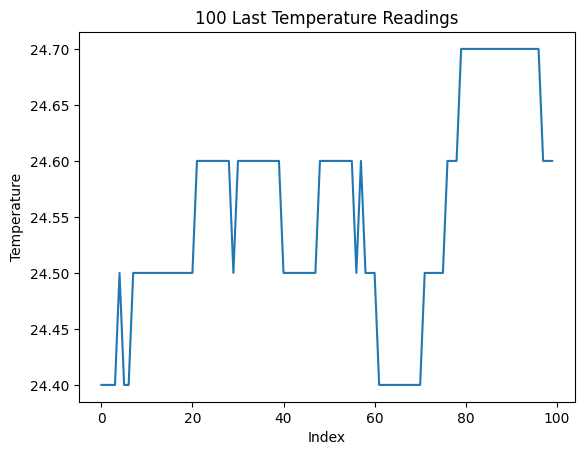

In [19]:
import matplotlib.pyplot as plt

values = []

for item in data:
    temp = float(item['value'])
    values.append(temp)

values.reverse()

plt.plot(values)
plt.title("100 Last Temperature Readings")
plt.xlabel("Index")
plt.ylabel("Temperature")

plt.show()